In [2]:
import uproot
# import NanoEvents and NanoAODSchema to read the NanoAOD files
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import matplotlib.pyplot as plt
import numpy as np
import awkward as ak
import mplhep as hep
hep.style.use("CMS")

# Set default figure size
plt.rcParams["figure.figsize"] = (10, 6)

CMAP_10 = [
    "#3f90da",
    "#ffa90e",
    "#bd1f01",
    "#94a4a2",
    "#832db6",
    "#a96b59",
    "#e76300",
    "#b9ac70",
    "#717581",
    "#92dadd",
]

COLOR_ALIASES = {
    "CMS_blue": CMAP_10[0],        # Blue
    "CMS_orange": CMAP_10[1],      # Orange
    "CMS_red": CMAP_10[2],         # Red
    "CMS_gray": CMAP_10[3],        # Gray
    "CMS_purple": CMAP_10[4],      # Purple
    "CMS_brown": CMAP_10[5],       # Brown
    "CMS_dark_orange": CMAP_10[6], # Dark Orange
    "CMS_beige": CMAP_10[7],       # Beige
    "CMS_dark_gray": CMAP_10[8],   # Dark Gray
    "CMS_light_blue": CMAP_10[9]   # Light Blue
}
CMS_blue = COLOR_ALIASES["CMS_blue"]
CMS_red = COLOR_ALIASES["CMS_red"]

In [3]:
filename = "muon_nano.root"
events = NanoEventsFactory.from_root(filename, schemaclass=NanoAODSchema).events()
events.fields

/home/mmarcheg/.local/micromamba/envs/pocket-coffea/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:205: RuntimeWarning: Missing cross-reference index for Electron_genPartIdx => GenPart
  warnings.warn(
/home/mmarcheg/.local/micromamba/envs/pocket-coffea/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:205: RuntimeWarning: Missing cross-reference index for Electron_jetIdx => Jet
  warnings.warn(
/home/mmarcheg/.local/micromamba/envs/pocket-coffea/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:205: RuntimeWarning: Missing cross-reference index for Electron_photonIdx => Photon
  warnings.warn(
/home/mmarcheg/.local/micromamba/envs/pocket-coffea/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:205: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/home/mmarcheg/.local/micromamba/envs/pocket-coffea/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:2

['SimTrack',
 'orbitNumber',
 'PFCand',
 'RecHitHGC',
 'TrackDisp',
 'SimHitHGCHEB',
 'event',
 'PFTICLCand',
 'MergedSimCluster',
 'TrackConv',
 'GenPart',
 'GenVtx',
 'run',
 'TrackingPart',
 'SimHitHGCEE',
 'CaloPart',
 'bunchCrossing',
 'SimCluster',
 'luminosityBlock',
 'Track',
 'SimHitHGCHEF']

In [4]:
events.RecHitHGC.fields

['detId',
 'energy',
 'time',
 'MergedSimCluster_MatchIdx',
 'MergedSimCluster_MatchQual',
 'SimCluster_MatchIdx',
 'SimCluster_MatchQual',
 'x',
 'y',
 'z',
 'hitr',
 'MergedSimClusterNumMatch',
 'MergedSimClusterBestMatchIdx',
 'MergedSimClusterBestMatchQual',
 'SimClusterNumMatch',
 'SimClusterBestMatchIdx',
 'SimClusterBestMatchQual']

In [5]:
nhits = ak.num(events.RecHitHGC.x)
print(np.mean(nhits), '+-', round(np.std(nhits), 1))

66677.2 +- 300.4


Text(0, 1, 'Events')

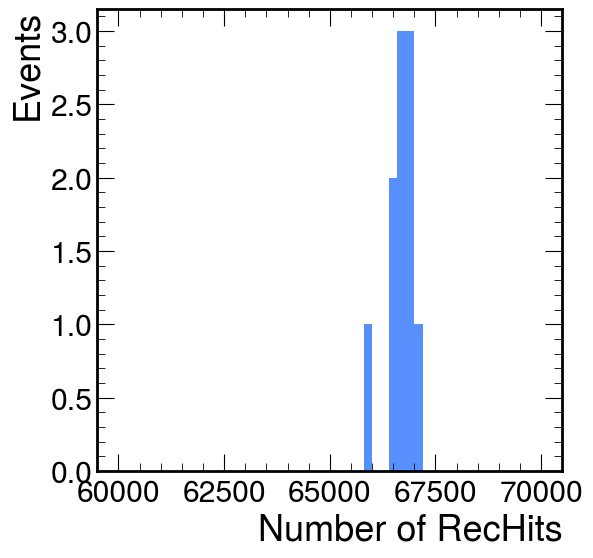

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.hist(nhits, bins=50, range=(60000, 70000))
ax.set_xlabel("Number of RecHits")
ax.set_ylabel("Events")

6280 9375
7742.3 +- 895.2


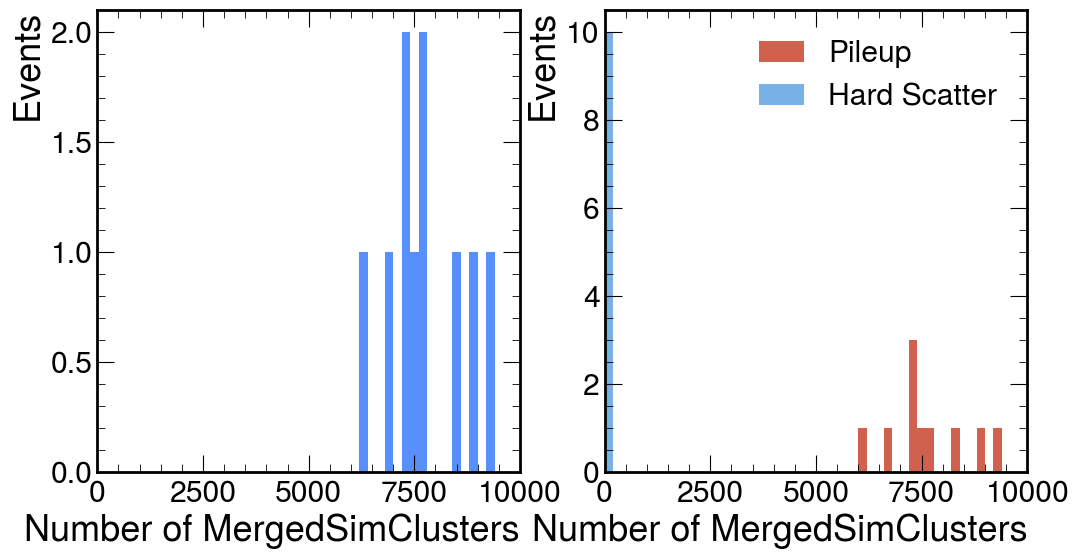

In [7]:
nclusters = ak.num(events.MergedSimCluster.impactPoint_x)
is_pileup = events.MergedSimCluster.eventId > 0
print(min(nclusters), max(nclusters))
print(np.mean(nclusters), '+-', round(np.std(nclusters), 1))
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
x_low, x_high = 0, 10000
ax[0].hist(nclusters, bins=50, range=(x_low, x_high))
ax[0].set_xlim(x_low, x_high)
ax[0].set_xlabel("Number of MergedSimClusters")
ax[0].set_ylabel("Events")
# Plot the distribution of nclusters for pileup and hard scatter events separately
ax[1].hist(ak.sum(is_pileup, axis=1), bins=50, range=(x_low, x_high), alpha=0.7, label='Pileup', color=CMS_red)
ax[1].hist(ak.sum(~is_pileup, axis=1), bins=50, range=(x_low, x_high), alpha=0.7, label='Hard Scatter', color=CMS_blue)
ax[1].set_xlim(x_low, x_high)
ax[1].set_xlabel("Number of MergedSimClusters")
ax[1].set_ylabel("Events")
ax[1].legend()

10514 15644
12935.9 +- 1503.1


Text(0, 1, 'Events')

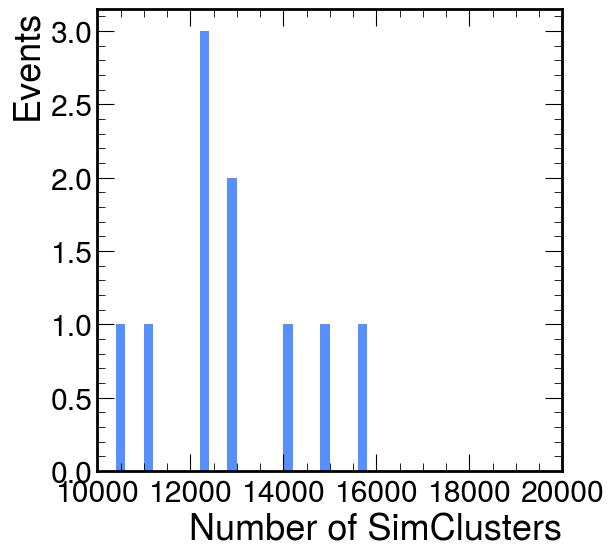

In [8]:
nsimclusters = ak.num(events.SimCluster.impactPoint_x)
print(min(nsimclusters), max(nsimclusters))
print(np.mean(nsimclusters), '+-', round(np.std(nsimclusters), 1))
fig, ax = plt.subplots(figsize=(6, 6))
x_low, x_high = 10000, 20000
ax.hist(nsimclusters, bins=50, range=(x_low, x_high))
ax.set_xlim(x_low, x_high)
ax.set_xlabel("Number of SimClusters")
ax.set_ylabel("Events")

Number of clusters in event 0: 6280
-1 6237
0.6169701073796376 +- 0.0028
Number of clusters in event 1: 8992
-1 8533
0.6175850227697381 +- 0.0028
Number of clusters in event 2: 7389
-1 7325
0.6179899670510238 +- 0.0028
Number of clusters in event 3: 7640
-1 7530
0.6192047998948811 +- 0.0028
Number of clusters in event 4: 7726
-1 7511
0.6207645852746482 +- 0.0028
Number of clusters in event 5: 8402
-1 8150
0.6181849402234948 +- 0.0028
Number of clusters in event 6: 9375
-1 9332
0.6165051713529763 +- 0.0028
Number of clusters in event 7: 7358
-1 7317
0.6121557698132409 +- 0.0028
Number of clusters in event 8: 7431
-1 7342
0.6204946224204576 +- 0.0028
Number of clusters in event 9: 6830
-1 6746
0.615665286917717 +- 0.0028


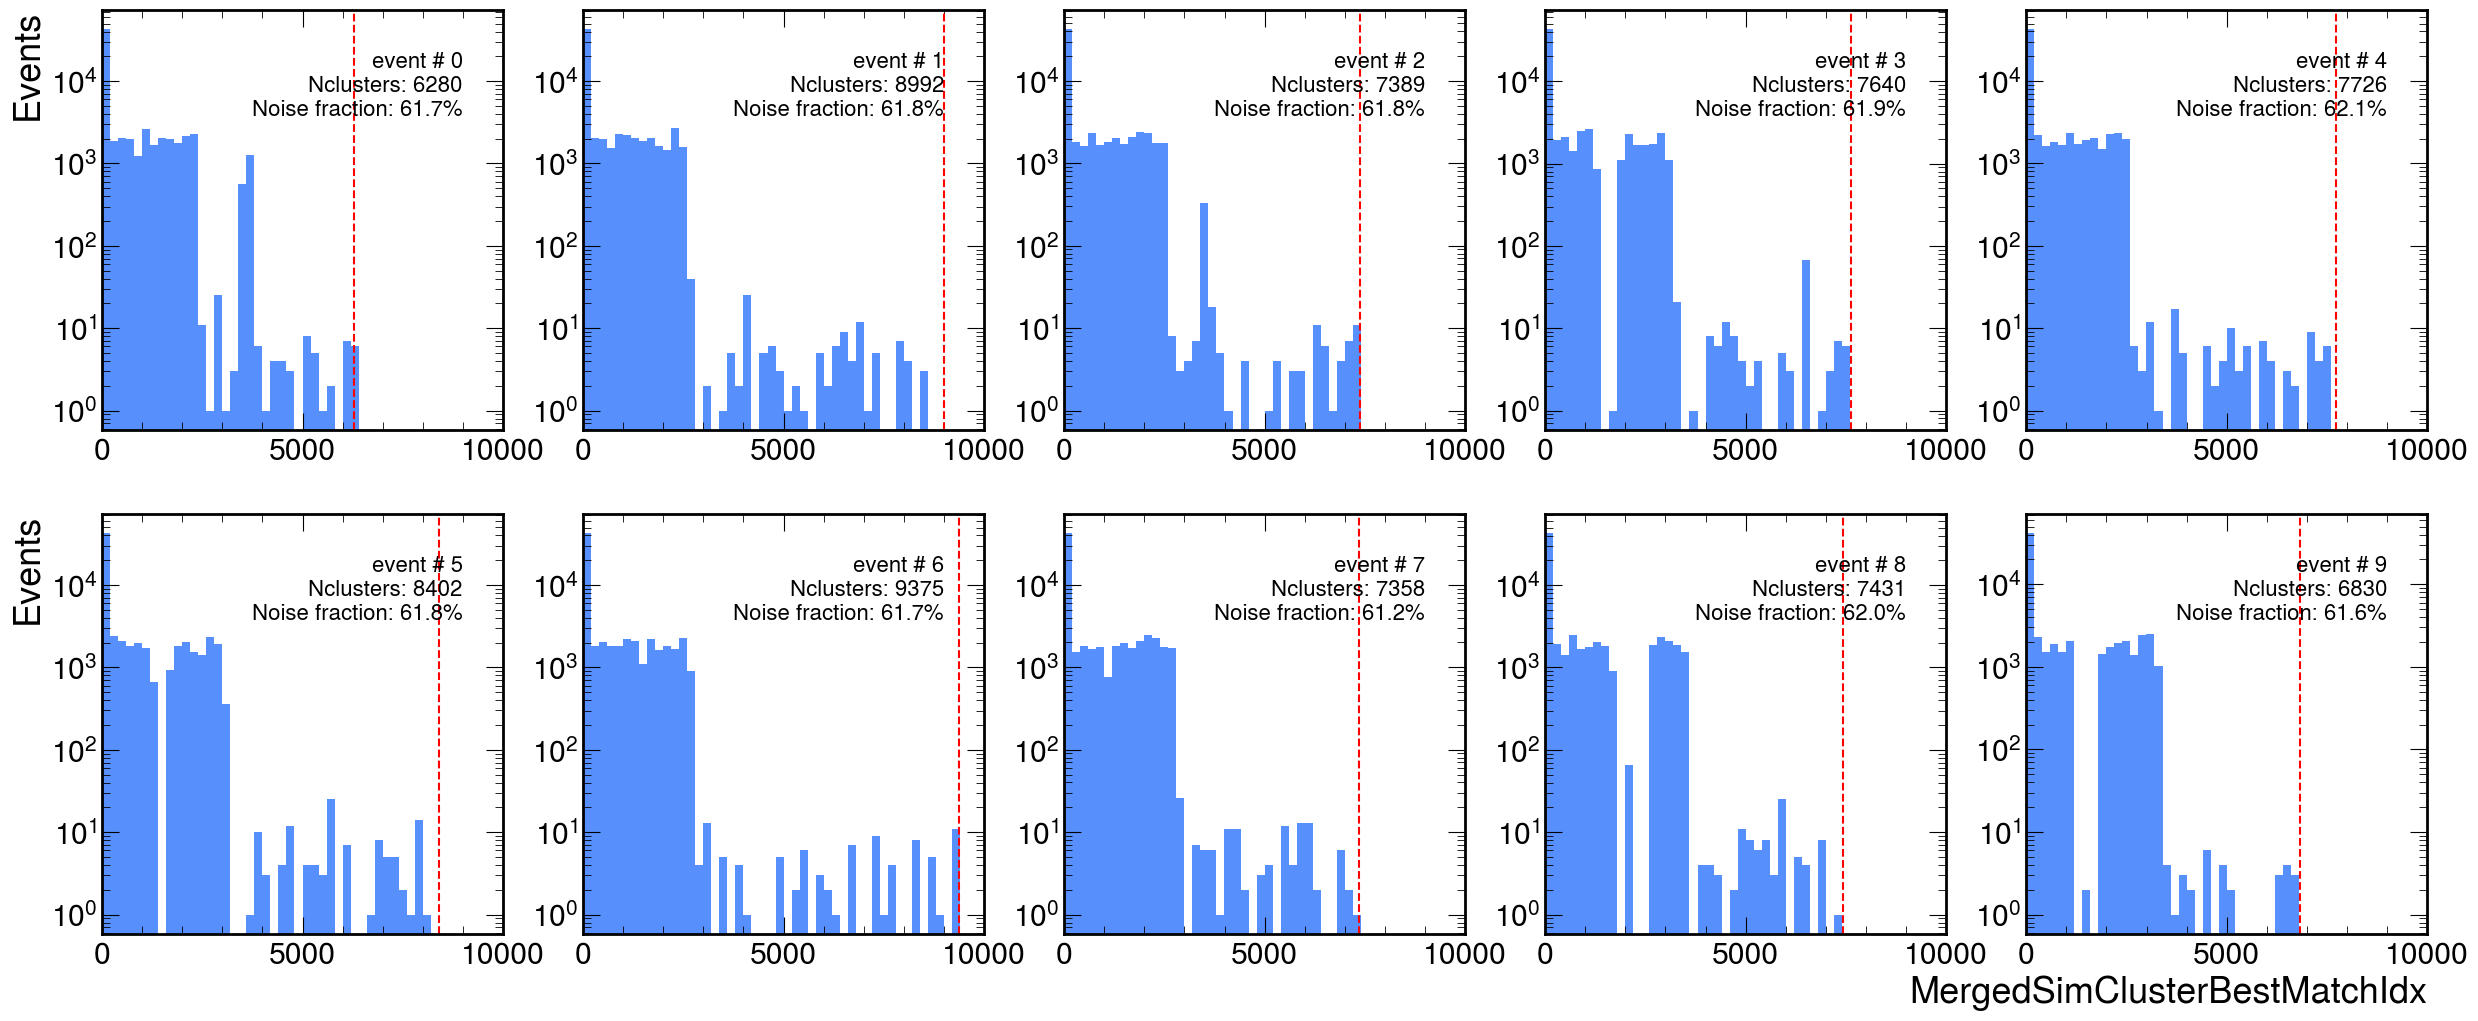

In [9]:
# Plot 10 events in 2 x 5 grid
fig, axs = plt.subplots(2, 5, figsize=(30, 12))
axs = axs.flatten()
for ievt, ax in enumerate(axs):
    print("Number of clusters in event {}: {}".format(ievt, nclusters[ievt]))
    idx_cluster = events.RecHitHGC.MergedSimClusterBestMatchIdx[ievt]
    print(min(idx_cluster), max(idx_cluster))
    is_noise = idx_cluster == -1
    noise_fraction = ak.sum(is_noise) / ak.num(events.RecHitHGC.x)
    print(np.mean(noise_fraction), '+-', round(np.std(noise_fraction), 4))
    x_low, x_high = -1, 10000
    ax.hist(idx_cluster, bins=50, range=(x_low, x_high))
    # Draw vertical line at ncluster
    ax.axvline(nclusters[ievt], 0, 1000, color="red", linestyle="--")
    ax.set_xlim(x_low, x_high)
    if ievt == 9:
        ax.set_xlabel("MergedSimClusterBestMatchIdx")
    if ievt % 5 == 0:
        ax.set_ylabel("Events")
    ax.set_yscale("log")
    # Add text to plot with noise fraction
    ax.text(
        0.9,
        0.9,
        "event # {}\nNclusters: {}\nNoise fraction: {:.1%}".format(ievt, nclusters[ievt], np.mean(noise_fraction)),
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=16,
    )

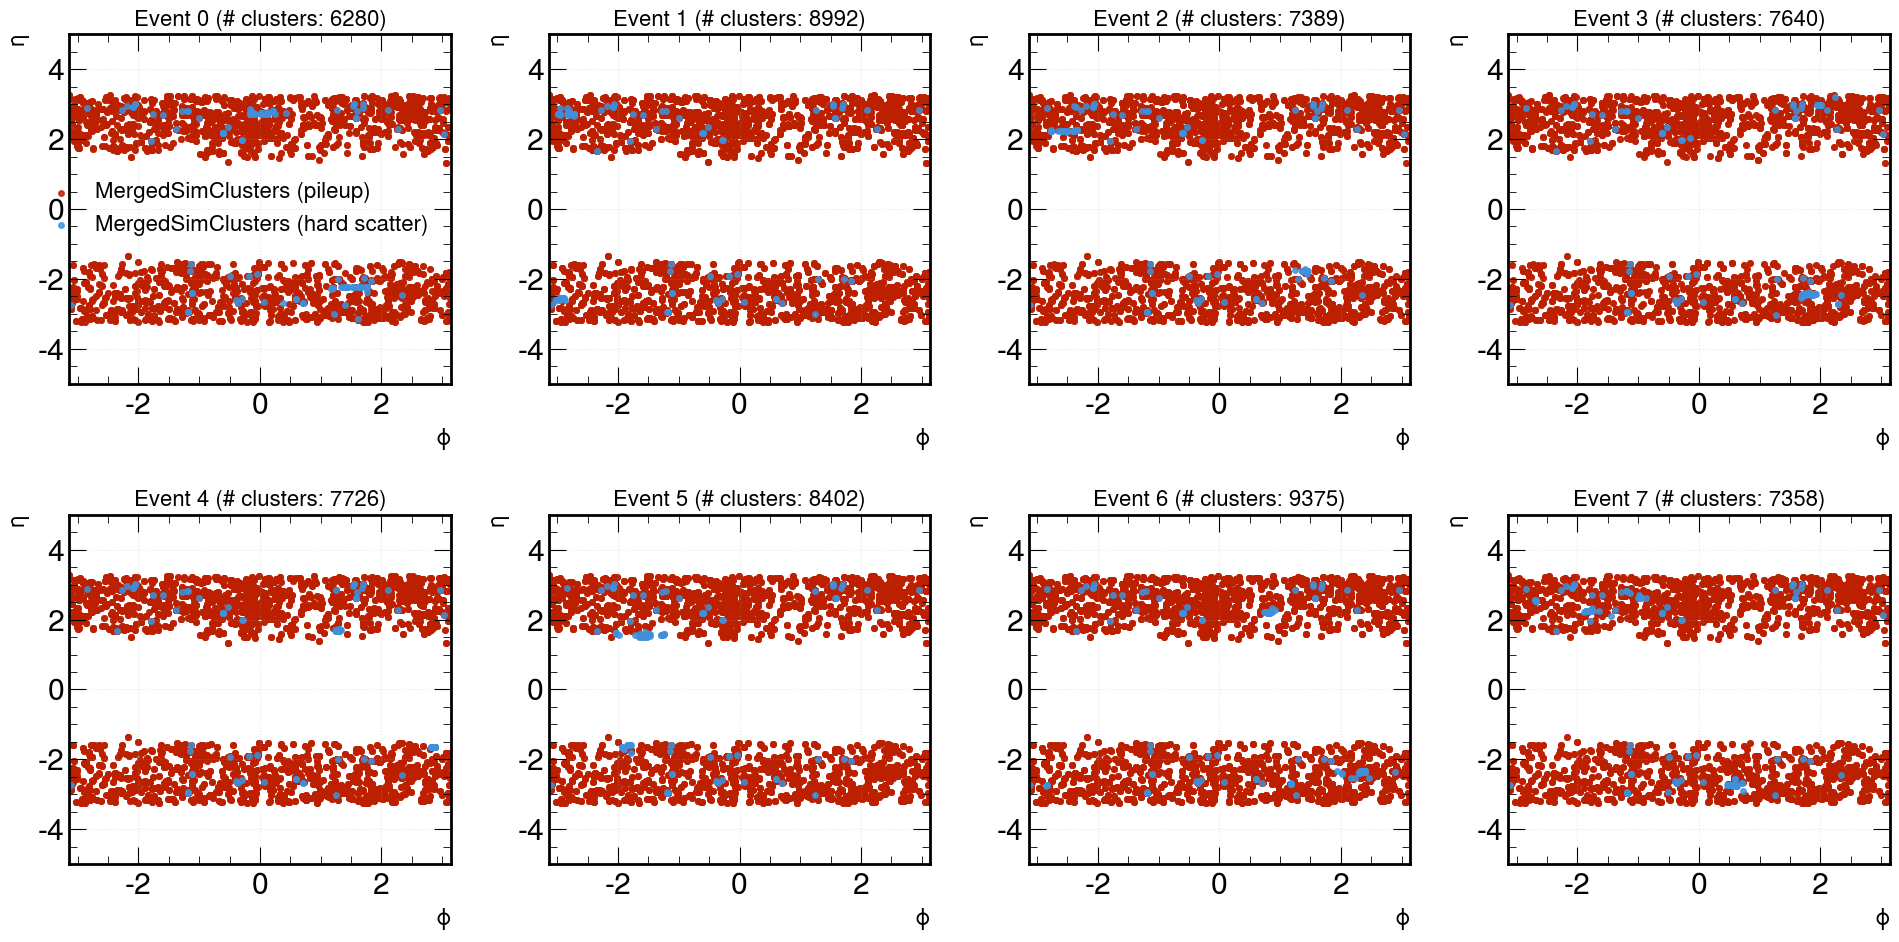

In [10]:
# Scatter plot of RecHitHGC eta vs phi and MergedSimCluster eta vs phi for first 10 events
num_events = 8
fontsize = 16
fig, axes = plt.subplots(2, num_events // 2, figsize=(num_events // 2 * 5, 10))
plt.subplots_adjust(hspace=0.3, wspace=0.3)

axes = axes.flatten()

for i in range(num_events):
    ax = axes[i]
    
    # Get RecHitHGC data for event i
    #rec_eta = events.RecHitHGC.eta[i]
    #rec_phi = events.RecHitHGC.phi[i]
    
    # Get MergedSimCluster data for event i
    merged_eta = events.MergedSimCluster.impactPoint_eta[i]
    merged_phi = events.MergedSimCluster.impactPoint_phi[i]
    
    # Plot RecHitHGC candidates with circles
    #ax.scatter(rec_phi, rec_eta, marker='o', s=50, alpha=1.0, 
    #           label='RecHitHGC Candidates', edgecolors=CMS_blue, color='none', linewidths=1.0)
    
    is_pileup = events.MergedSimCluster.eventId[i] > 0

    # Plot MergedSimClusters with red crosses
    ax.scatter(merged_phi[is_pileup], merged_eta[is_pileup], marker='.', s=50, c=CMS_red, alpha=0.8, 
               label='MergedSimClusters (pileup)', linewidths=1.5)
    ax.scatter(merged_phi[~is_pileup], merged_eta[~is_pileup], marker='.', s=50, c=CMS_blue, alpha=0.8, 
               label='MergedSimClusters (hard scatter)', linewidths=1.5)
    ax.set_xlim(-3.14, 3.14)
    ax.set_ylim(-5, 5)
    ax.set_xlabel(r"$\phi$", fontsize=fontsize)
    ax.set_ylabel(r"$\eta$", fontsize=fontsize)
    ax.set_title(f'Event {i} (# clusters: {len(merged_eta)})', fontsize=fontsize)
    ax.grid(True, alpha=0.3)
    
    # Only show legend on first plot to avoid clutter
    if i == 0:
        ax.legend(fontsize=fontsize)

plt.tight_layout()
plt.show()

In [11]:
events.TrackConv.Vtx_x

<Array [[], [], [], [], ... [], [], [], []] type='10 * var * float32[parameters=...'>

11.242963977112744 +- 21.6
Single-hit MergedSimClusters: 27.3%
Less than 5 hits: 55.2%
Less than 10 hits: 70.4%


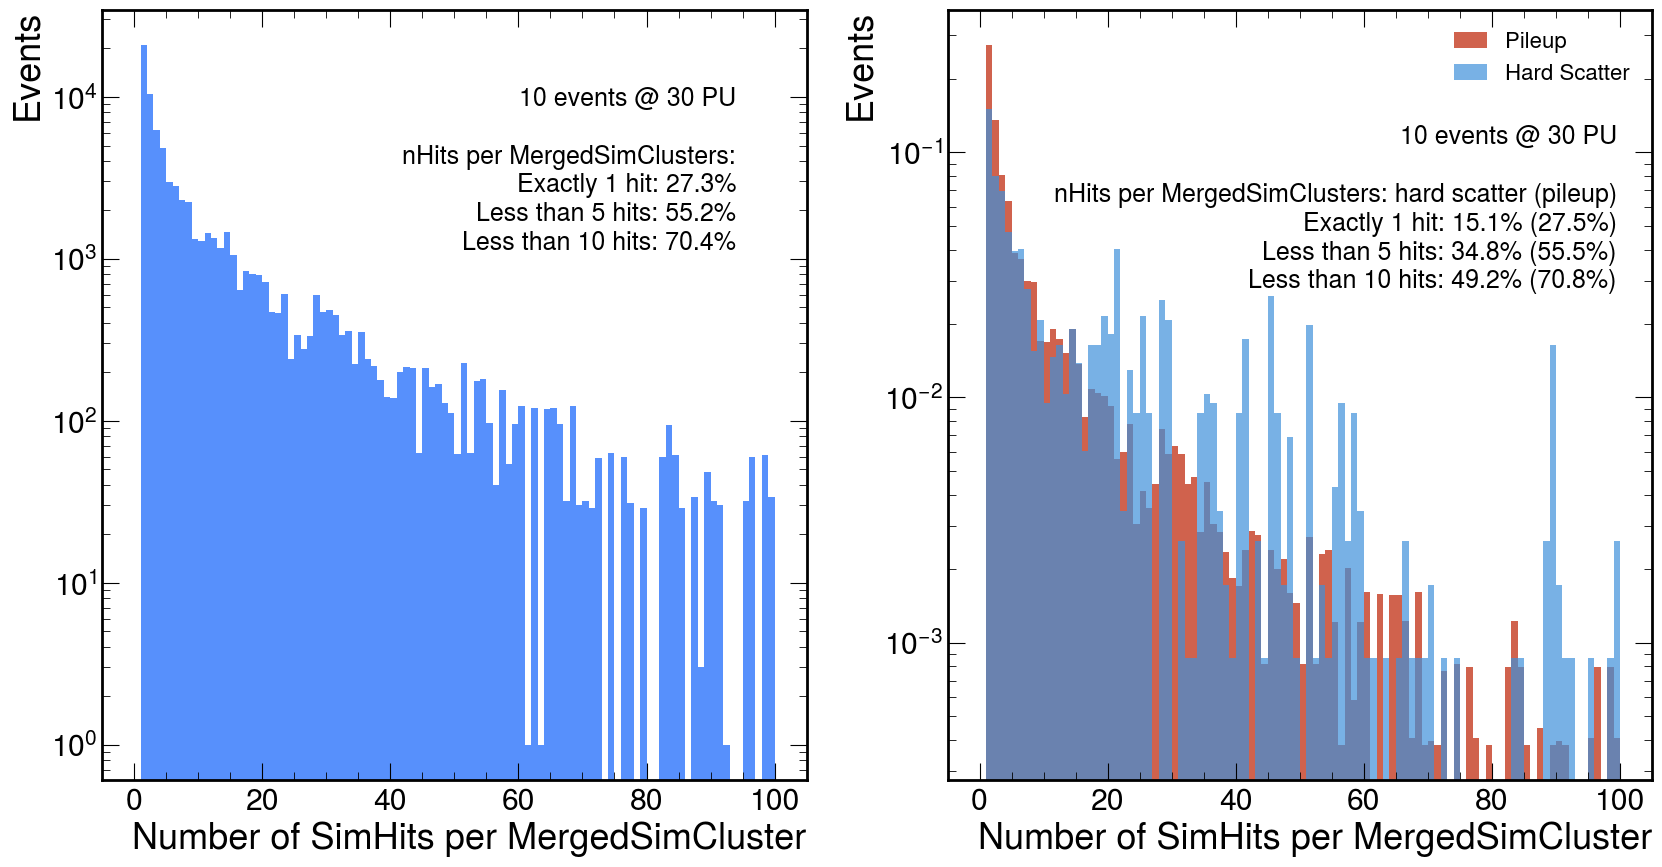

In [12]:
# Plot number of hits per MergedSimCluster
nhits_per_cluster = events.MergedSimCluster.nHits
is_pileup = (events.MergedSimCluster.eventId != 0) | (events.MergedSimCluster.bunchCrossing != 0)
print(np.mean(nhits_per_cluster), '+-', round(np.std(nhits_per_cluster), 1))
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
n, bins, patches = ax[0].hist(ak.flatten(nhits_per_cluster), bins=100, range=(0, 100))
single_hit_fraction = n[1] / np.sum(n)
# compute fraction of MergedSimClusters with less than 5 hits
less_than_5_fraction = np.sum(n[:5]) / np.sum(n)
less_than_10_fraction = np.sum(n[:10]) / np.sum(n)
ax[0].set_xlabel("Number of SimHits per MergedSimCluster")
ax[0].set_ylabel("Events")
ax[0].set_yscale("log")
ax[0].text(
    0.9,
    0.9,
    "10 events @ 30 PU\n\nnHits per MergedSimClusters:\nExactly 1 hit: {:.1%}".format(single_hit_fraction) + "\nLess than 5 hits: {:.1%}".format(less_than_5_fraction) + "\nLess than 10 hits: {:.1%}".format(less_than_10_fraction),
    transform=ax[0].transAxes,
    ha="right",
    va="top",
    fontsize=18,
)

# Plot distribution of nHits for pileup and hard scatter MergedSimClusters separately (density plot to better compare shapes)
n_pileup, bins, patches = ax[1].hist(ak.flatten(nhits_per_cluster[is_pileup]), bins=100, range=(0, 100), alpha=0.7, label='Pileup', color=CMS_red, density=True)
n_hard_scatter, bins, patches = ax[1].hist(ak.flatten(nhits_per_cluster[~is_pileup]), bins=100, range=(0, 100), alpha=0.7, label='Hard Scatter', color=CMS_blue, density=True)
ax[1].set_xlabel("Number of SimHits per MergedSimCluster")
ax[1].set_ylabel("Events")
ax[1].set_yscale("log")
ax[1].legend(fontsize=16)
single_hit_fraction_pileup = n_pileup[1] / np.sum(n_pileup)
single_hit_fraction_hard_scatter = n_hard_scatter[1] / np.sum(n_hard_scatter)
less_than_5_fraction_pileup = np.sum(n_pileup[:5]) / np.sum(n_pileup)
less_than_5_fraction_hard_scatter = np.sum(n_hard_scatter[:5]) / np.sum(n_hard_scatter)
less_than_10_fraction_pileup = np.sum(n_pileup[:10]) / np.sum(n_pileup)
less_than_10_fraction_hard_scatter = np.sum(n_hard_scatter[:10]) / np.sum(n_hard_scatter)
ax[1].text(
    0.95,
    0.85,
    "10 events @ 30 PU\n\nnHits per MergedSimClusters: hard scatter (pileup)\nExactly 1 hit: {:.1%} ({:.1%})".format(single_hit_fraction_hard_scatter, single_hit_fraction_pileup) + "\nLess than 5 hits: {:.1%} ({:.1%})".format(less_than_5_fraction_hard_scatter, less_than_5_fraction_pileup) + "\nLess than 10 hits: {:.1%} ({:.1%})".format(less_than_10_fraction_hard_scatter, less_than_10_fraction_pileup),
    transform=ax[1].transAxes,
    ha="right",
    va="top",
    fontsize=18,
)

# Compute fraction of MergedSimClusters with just one hit
print("Single-hit MergedSimClusters: {:.1%}".format(single_hit_fraction))
print("Less than 5 hits: {:.1%}".format(less_than_5_fraction))
print("Less than 10 hits: {:.1%}".format(less_than_10_fraction))

In [13]:
events.SimCluster.nHits

<Array [[114, 1, 5, 3, 3, ... 5, 1, 6, 3, 1]] type='10 * var * int32[parameters=...'>

In [14]:
events.MergedSimCluster.nHits

<Array [[124, 5, 3, 3, 3, ... 14, 1, 5, 1, 6]] type='10 * var * int32[parameters...'>

0 37


Text(0, 1, 'SimClusters')

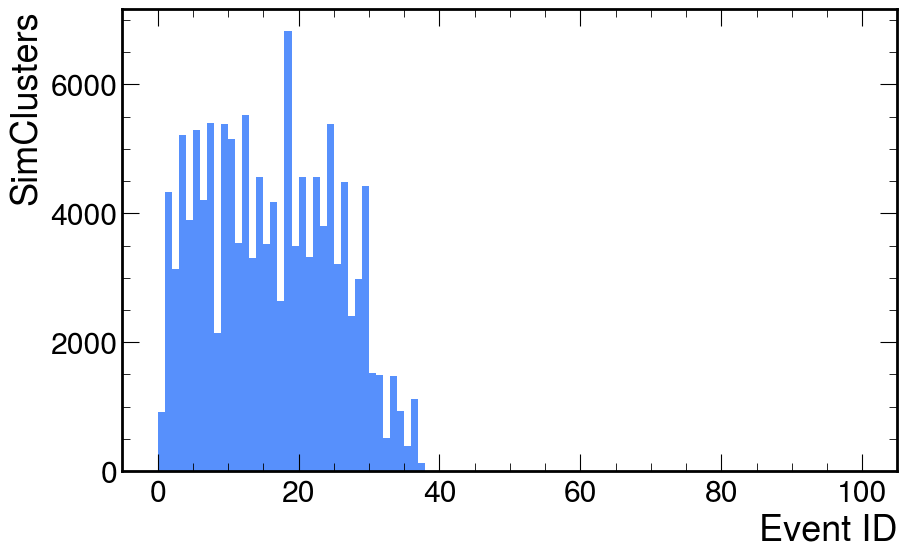

In [15]:
eventid = ak.flatten(events.SimCluster.eventId)
print(min(eventid), max(eventid))
# Plot the event IDs of the SimClusters
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(eventid, bins=100, range=(0, 100))
ax.set_xlabel("Event ID")
ax.set_ylabel("SimClusters")

In [16]:
events.MergedSimCluster.eventId[0].tolist()

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 0,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 0,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,


In [17]:
events.SimCluster.eventId

<Array [[0, 0, 0, 0, 0, ... 27, 27, 27, 27]] type='10 * var * int32[parameters={...'>